In [2]:
import os
import numpy as np
import pandas as pd

from scipy.io import loadmat
from scipy.ndimage import gaussian_filter

from skimage.transform import warp, EuclideanTransform, rotate

from joblib import Parallel, delayed

#Transformation function - Andrew Mocle
def euclid_tx(img, params):
    """
    params = (rotation_degrees, dx, dy)
    """
    tx = EuclideanTransform(rotation=0, translation=params[1:])
    img_tx = warp(rotate(img, params[0], preserve_range=True), tx, preserve_range=True)
    return img_tx


#Grab your red tagged cells
def get_tagged_cells(stat, red, filt_sigma=10, thresh_intensity=0.2, thresh_correlation=0.2):
    """
    Returns boolean array is_eng per ROI:
      is_eng[n] = (mean red_norm in ROI > thresh_intensity) AND
                  (corr(red pixels in ROI, ROI weights lam) > thresh_correlation)

    Expects Suite2p stat entries to include:
      stat[n]["xpix"], stat[n]["ypix"], stat[n]["lam"]
    """
    red_filt = gaussian_filter(red, filt_sigma)
    red_norm = (red - red_filt) / red_filt

    r_values = []
    corr_values = []
    for n in range(len(stat)):
        if stat[n] is not None and "ypix" in stat[n]:
            r_values.append(np.mean(red_norm[stat[n]["ypix"], stat[n]["xpix"]]))
            corr_values.append(np.corrcoef(red[stat[n]["ypix"], stat[n]["xpix"]], stat[n]["lam"])[0, 1])
        else:
            r_values.append(0)
            corr_values.append(0)

    is_eng = (np.array(r_values) > thresh_intensity) & (np.array(corr_values) > thresh_correlation)
    return is_eng


def get_tagged_cells_multisess(mouse, red_sess, filt_sigma=10, thresh_intensity=0.4,
                              thresh_correlation=0.3, shift_field=False):
    """
    mouse is a dict like:
      mouse[red_sess]["red"] = 2D red image
      mouse[sess]["stat"] = suite2p stats per session, where sess keys contain "tp"

    Strategy:
      - compute r_value and corr_value per (cell_id, session)
      - for each cell_id, pick the session where corr_value is best
      - threshold r_value and corr_value at that best session
    """
    red = mouse[red_sess]["red"]
    red_filt = gaussian_filter(red, filt_sigma)
    red_norm = (red - red_filt) / red_filt

    if shift_field:
        dx, dy = np.random.randint(-20, 20), np.random.randint(-20, 20)
        dr = 5 * (np.random.rand() - 0.5)
        red_norm = euclid_tx(red_norm, (dr, dx, dy))

    cell_statistics = {"r_values": [], "corr_values": [], "sess": [], "cell_id": []}
    sessions = [k for k in mouse.keys() if "tp" in k]
    for sess in sessions:
        stat = mouse[sess]["stat"]
        for n in range(len(stat)):
            if stat[n] is not None:
                cell_statistics["r_values"].append(np.mean(red_norm[stat[n]["ypix"], stat[n]["xpix"]]))
                cell_statistics["corr_values"].append(np.corrcoef(
                    red[stat[n]["ypix"], stat[n]["xpix"]], stat[n]["lam"]
                )[0, 1])
                cell_statistics["sess"].append(sess)
                cell_statistics["cell_id"].append(n)
            else:
                cell_statistics["r_values"].append(0)
                cell_statistics["corr_values"].append(0)
                cell_statistics["sess"].append(sess)
                cell_statistics["cell_id"].append(n)

    df = pd.DataFrame(cell_statistics)

    best_sessions = {"cell_id": [], "sess": [], "r_value": [], "corr_value": []}
    footprints = []

    df.loc[df["corr_values"] == 0, "corr_values"] = -2

    for n in df["cell_id"].unique():
        df_cell = df[df["cell_id"] == n]
        best_idx = np.flipud(np.argsort(df_cell["corr_values"].values))[0]
        best_sess = df_cell["sess"].values[best_idx]

        best_sessions["sess"].append(best_sess)
        best_sessions["cell_id"].append(n)
        best_sessions["r_value"].append(df_cell["r_values"].values[best_idx])
        best_sessions["corr_value"].append(df_cell["corr_values"].values[best_idx])

        footprints.append(mouse[best_sess]["stat"][n])

    best_sessions = pd.DataFrame(best_sessions)
    is_eng = (best_sessions["r_value"] > thresh_intensity) & (best_sessions["corr_value"] > thresh_correlation)

    return is_eng, footprints


# 3) Activity graph / shuffle controls
def build_graph_shuffle_parallel(activity, n_shuffles=1000, sd_thresh=3, n_threads=20):
    """
    activity: (cells x time)
    Returns:
      data_adj_cut: boolean adjacency where z-scored corr > sd_thresh
      data_adj: z-scored corr matrix relative to time-shift shuffle null
    """

    def shuf_1chunk(activity, n_shuffles_chunk, fs=5):
        shuffle_stack = np.zeros((activity.shape[0], activity.shape[0], n_shuffles_chunk))
        activity_shuf = activity.copy()

        for ss in range(shuffle_stack.shape[2]):
            for nn in range(activity_shuf.shape[0]):
                activity_shuf[nn, :] = np.roll(activity[nn, :], np.random.randint(-300 * fs, 300 * fs))

            shuffle_stack[:, :, ss] = np.nan_to_num(np.corrcoef(activity_shuf, rowvar=True))
        return shuffle_stack

    n_shuffles_chunk = int(np.ceil(n_shuffles / n_threads))
    shuffle_chunks = Parallel(n_jobs=n_threads)(
        delayed(shuf_1chunk)(activity, n_shuffles_chunk) for _ in range(n_threads)
    )

    shuffle_stack = np.array([]).reshape(activity.shape[0], activity.shape[0], 0)
    for cc in range(len(shuffle_chunks)):
        shuffle_stack = np.concatenate((shuffle_stack, shuffle_chunks[cc]), axis=2)

    with np.errstate(divide="ignore", invalid="ignore"):
        shuf_mean = np.mean(shuffle_stack, axis=2)
        shuf_std = np.std(shuffle_stack, axis=2)

        data_corr = np.corrcoef(activity, rowvar=True)
        data_adj = np.nan_to_num((data_corr - shuf_mean) / shuf_std)

    data_adj_cut = data_adj > sd_thresh
    return data_adj_cut, data_adj


def scramble(arr):
    """
    Permute cell identities independently at each timepoint (each column).
    """
    arr_copy = arr.copy()
    for tt in range(arr_copy.shape[1]):
        idx = np.random.permutation(np.arange(arr_copy.shape[0]))
        arr_copy[:, tt] = arr_copy[:, tt][idx]
    return arr_copy


def activation_score(activity, ensembles, n_shuffles=100):
    """
    activity: (cells x time)
    ensembles: (cells x n_ensembles)
    Computes z-scored ensemble activation over time vs scrambled-ensemble null.
    Returns: (time x n_ensembles)
    """
    actual = ensembles.T @ activity  # (ensembles x time)

    activation_shuff = np.zeros((ensembles.shape[1], activity.shape[1], n_shuffles))
    for ss in range(n_shuffles):
        ensembles_shuff = scramble(ensembles)
        activation_shuff[:, :, ss] = ensembles_shuff.T @ activity

    scores = (actual - np.nanmean(activation_shuff, axis=2)) / (np.nanstd(activation_shuff, axis=2))
    return scores.T  # (time x ensembles)


def jitter(arr):
    """
    Circularly shift each cell trace by a random amount (break synchrony).
    arr: (cells x time)
    """
    arr_copy = arr.copy()
    for nn in range(arr_copy.shape[0]):
        arr_copy[nn, :] = np.roll(arr_copy[nn, :], np.random.randint(-200, 200))
    return arr_copy


def ds_avg(arr, bin_factor):
    """
    Downsample by averaging in non-overlapping bins along time dimension.
    Supports:
      - 2D (cells x time)
      - 1D (time,)
    """
    if arr.ndim == 2:
        arr_ds = np.zeros((arr.shape[0], int(np.floor(arr.shape[1] / bin_factor))))
        for tt in range(arr_ds.shape[1]):
            arr_ds[:, tt] = np.mean(arr[:, bin_factor * tt:bin_factor * tt + bin_factor], axis=1)
        return arr_ds

    elif arr.ndim == 1:
        arr_ds = np.zeros(int(np.floor(len(arr) / bin_factor)))
        for tt in np.arange(len(arr_ds)):
            arr_ds[tt] = np.mean(arr[bin_factor * tt:bin_factor * tt + bin_factor])
        return arr_ds

    else:
        raise ValueError("ds_avg supports only 1D or 2D arrays.")


#Suite2p MAT helpers (two-file: green mat + red mat)
import h5py
import numpy as np

def load_suite2p_green_h5(mat_path):
    """
    Loads Suite2p green v7.3 .mat using h5py.
    Returns:
      stat : list of dicts with ypix/xpix/lam
      good : boolean iscell mask
    """
    with h5py.File(mat_path, "r") as f:
        # --- iscell ---
        iscell = np.array(f["iscell"])
        if iscell.shape[0] == 2:
            good = iscell[0, :].astype(bool)
        else:
            good = iscell[:, 0].astype(bool)

        # --- stat ---
        stat_refs = f["stat"]
        stat = []
        for i in range(stat_refs.shape[0]):
            g = f[stat_refs[i, 0]]
            stat.append({
                "ypix": np.array(g["ypix"]).astype(int),
                "xpix": np.array(g["xpix"]).astype(int),
                "lam":  np.array(g["lam"]).astype(float),
            })

    return stat, good


def load_suite2p_red_meanImg_h5(mat_path):
    """
    Loads ops['meanImg'] from a red Suite2p v7.3 .mat using h5py.
    """
    with h5py.File(mat_path, "r") as f:
        ops = f["ops"]
        red = np.array(ops["meanImg"]).astype(np.float32)
    return red


def roi_bounds_check(stat, img2d):
    """
    Verify ROI pixel indices fit within image.
    """
    max_y = max(int(np.max(s["ypix"])) for s in stat if s is not None and "ypix" in s)
    max_x = max(int(np.max(s["xpix"])) for s in stat if s is not None and "xpix" in s)
    if max_y >= img2d.shape[0] or max_x >= img2d.shape[1]:
        raise ValueError(
            f"ROI coords exceed image bounds. "
            f"max_y,max_x={max_y},{max_x} vs img shape={img2d.shape}. "
            f"Likely mismatch in cropping/registration."
        )
    return max_y, max_x

#MAIN: run engram tagging from two Suite2p mats
def tag_engram_from_two_suite2p_mats(
    green_mat_path,
    red_mat_path,
    filt_sigma=10,
    thresh_intensity=0.2,
    thresh_correlation=0.2,
    save_csv_path=None
):
    """
    Uses:
      - GREEN suite2p mat: stat + iscell
      - RED suite2p mat: ops['meanImg']
    Returns:
      is_eng (all ROIs)
      is_eng_cells (restricted to iscell==1)
      df summary
    """
    stat, good, _opsG = load_suite2p_green(green_mat_path)
    red, _opsR = load_suite2p_red_meanImg(red_mat_path)

    roi_bounds_check(stat, red)

    is_eng = get_tagged_cells(
        stat, red,
        filt_sigma=filt_sigma,
        thresh_intensity=thresh_intensity,
        thresh_correlation=thresh_correlation
    )
    is_eng = np.array(is_eng).astype(bool)
    is_eng_cells = is_eng & good

    df = pd.DataFrame({
        "cell_id": np.arange(len(stat)),
        "iscell": good.astype(int),
        "is_eng": is_eng.astype(int),
        "is_eng_cells": is_eng_cells.astype(int),
        "green_mat": os.path.basename(green_mat_path),
        "red_mat": os.path.basename(red_mat_path),
    })

    if save_csv_path is not None:
        df.to_csv(save_csv_path, index=False)

    return is_eng, is_eng_cells, df



In [3]:

if __name__ == "__main__":
    green_mat = "/Users/suthardr/Desktop/akemi/green/Fall_cellsOnly.mat"
    red_mat   = "/Users/suthardr/Desktop/akemi/red/Fall_cellsOnly.mat"

    is_eng, is_eng_cells, df = tag_engram_from_two_suite2p_mats(
        green_mat,
        red_mat,
        filt_sigma=10,
        thresh_intensity=0.2,
        thresh_correlation=0.2,
        save_csv_path="engram_tags.csv"
    )

    print("Total ROIs:", len(is_eng))
    print("Tagged (all ROIs):", int(is_eng.sum()))
    print("Tagged (iscell only):", int(is_eng_cells.sum()))
    print(df.head())


NotImplementedError: Please use HDF reader for matlab v7.3 files, e.g. h5py

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.measure import find_contours


def _roi_contour_from_stat_entry(s, Ly, Lx):
    """
    Build a contour (y,x) for one Suite2p ROI using its ypix/xpix.
    Returns a list of contours (each is Nx2 array of [y,x]) or [] if none.
    """
    if s is None or ("ypix" not in s) or ("xpix" not in s):
        return []

    ypix = np.asarray(s["ypix"]).astype(int)
    xpix = np.asarray(s["xpix"]).astype(int)

    # bounds safety
    keep = (ypix >= 0) & (ypix < Ly) & (xpix >= 0) & (xpix < Lx)
    if not np.any(keep):
        return []

    ypix = ypix[keep]
    xpix = xpix[keep]

    mask = np.zeros((Ly, Lx), dtype=np.uint8)
    mask[ypix, xpix] = 1

    # find_contours expects "1" regions; returns list of (row,col) coords
    contours = find_contours(mask, level=0.5)
    return contours


def plot_engram_cells(
    red_img,
    stat,
    is_eng,
    good_mask=None,
    title="Engram cells on red mean image",
    show_non_engram=True,
    alpha_bg=1.0,
    lw_eng=1.8,
    lw_non=0.8,
    annotate=False,
    annotate_only_engram=True,
    max_annotations=200,
    figsize=(10, 10),
):
    """
    Visualize engram-tagged ROIs overlaid on the red Suite2p ops['meanImg'].

    Parameters
    ----------
    red_img : (Ly, Lx) array
        Typically red ops['meanImg'].
    stat : list
        Suite2p stat list; each entry has ypix/xpix/lam.
    is_eng : (N,) bool
        Output of get_tagged_cells(...).
    good_mask : (N,) bool or None
        Optional iscell mask to restrict plotting to accepted cells.
    show_non_engram : bool
        If True, plots non-engram ROIs too (fainter).
    annotate : bool
        If True, writes ROI indices at ROI centroids.
    annotate_only_engram : bool
        If True, only labels engram ROIs.
    max_annotations : int
        Cap label count to avoid clutter.
    """
    red = np.asarray(red_img)
    Ly, Lx = red.shape[:2]

    is_eng = np.asarray(is_eng).astype(bool)
    if good_mask is None:
        good_mask = np.ones_like(is_eng, dtype=bool)
    else:
        good_mask = np.asarray(good_mask).astype(bool)

    # Only consider good cells for overlay decisions
    eng_mask = is_eng & good_mask
    non_mask = (~is_eng) & good_mask

    fig, ax = plt.subplots(1, 1, figsize=figsize)
    ax.imshow(red, cmap="gray", alpha=alpha_bg)
    ax.set_title(title)
    ax.set_axis_off()

    # Plot non-engram outlines first (under)
    if show_non_engram:
        for i in np.where(non_mask)[0]:
            contours = _roi_contour_from_stat_entry(stat[i], Ly, Lx)
            for c in contours:
                ax.plot(c[:, 1], c[:, 0], linewidth=lw_non, alpha=0.35)  # default line color

    # Plot engram outlines on top
    for i in np.where(eng_mask)[0]:
        contours = _roi_contour_from_stat_entry(stat[i], Ly, Lx)
        for c in contours:
            ax.plot(c[:, 1], c[:, 0], linewidth=lw_eng, alpha=0.9)

    # Optional annotations at centroid
    if annotate:
        idxs = np.where(eng_mask if annotate_only_engram else good_mask)[0]
        if len(idxs) > max_annotations:
            idxs = idxs[:max_annotations]

        for i in idxs:
            s = stat[i]
            if s is None or ("ypix" not in s) or ("xpix" not in s):
                continue
            y = np.mean(np.asarray(s["ypix"]))
            x = np.mean(np.asarray(s["xpix"]))
            ax.text(x, y, str(i), fontsize=8, ha="center", va="center")

    # Simple legend proxy
    n_eng = int(eng_mask.sum())
    n_good = int(good_mask.sum())
    ax.text(
        0.01, 0.99,
        f"Tagged (engram): {n_eng} / {n_good} (iscell)" if good_mask is not None else f"Tagged: {n_eng}/{len(is_eng)}",
        transform=ax.transAxes,
        ha="left", va="top",
        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none", pad=4),
    )

    return fig, ax


def plot_engram_zoom_panels(
    red_img,
    stat,
    is_eng,
    centers=None,
    box_halfwidth=60,
    good_mask=None,
    n_panels=6,
    figsize=(14, 8),
):
    """
    Convenience: show several zoomed-in panels around selected engram cells.
    centers: list of ROI indices to center on. If None, uses first n engram ROIs.
    """
    red = np.asarray(red_img)
    Ly, Lx = red.shape

    is_eng = np.asarray(is_eng).astype(bool)
    if good_mask is None:
        good_mask = np.ones_like(is_eng, dtype=bool)
    else:
        good_mask = np.asarray(good_mask).astype(bool)

    eng_idxs = np.where(is_eng & good_mask)[0]
    if centers is None:
        centers = eng_idxs[:n_panels].tolist()
    else:
        centers = centers[:n_panels]

    n = len(centers)
    if n == 0:
        raise ValueError("No engram cells available to plot.")

    ncols = min(3, n)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = np.atleast_1d(axes).ravel()

    for ax, idx in zip(axes, centers):
        s = stat[idx]
        if s is None or ("ypix" not in s) or ("xpix" not in s):
            ax.set_axis_off()
            continue

        cy = int(np.round(np.mean(np.asarray(s["ypix"]))))
        cx = int(np.round(np.mean(np.asarray(s["xpix"]))))

        y0 = max(0, cy - box_halfwidth)
        y1 = min(Ly, cy + box_halfwidth)
        x0 = max(0, cx - box_halfwidth)
        x1 = min(Lx, cx + box_halfwidth)

        ax.imshow(red[y0:y1, x0:x1], cmap="gray")
        ax.set_title(f"ROI {idx} (engram)")
        ax.set_axis_off()

        # overlay contours within the crop
        contours = _roi_contour_from_stat_entry(s, Ly, Lx)
        for c in contours:
            ax.plot(c[:, 1] - x0, c[:, 0] - y0, linewidth=2, alpha=0.9)

    # turn off extra axes
    for ax in axes[len(centers):]:
        ax.set_axis_off()

    return fig, axes


# -------------------------
# Example usage
# -------------------------
# red = np.array(R["ops"]["meanImg"]).astype(np.float32)
# stat, good, _ = load_suite2p_green(green_mat)
# is_eng = get_tagged_cells(stat, red, filt_sigma=10, thresh_intensity=0.2, thresh_correlation=0.2)
# fig, ax = plot_engram_cells(red, stat, is_eng, good_mask=good, annotate=False)
# plt.show()
#
# fig2, _ = plot_engram_zoom_panels(red, stat, is_eng, good_mask=good, box_halfwidth=70, n_panels=6)
# plt.show()


In [20]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from skimage.measure import find_contours
from scipy.ndimage import gaussian_filter


def load_green_stat_iscell(green_mat_path):
    with h5py.File(green_mat_path, "r") as f:
        # iscell: usually shape (2, N) in Suite2p exports
        iscell = np.array(f["iscell"])
        good = iscell[0, :].astype(bool) if iscell.shape[0] == 2 else iscell[:, 0].astype(bool)

        # stat: object refs -> dereference each ROI group
        stat_refs = f["stat"]
        stat = []
        for i in range(stat_refs.shape[0]):
            g = f[stat_refs[i, 0]]
            stat.append({
                "ypix": np.array(g["ypix"]).astype(int).squeeze(),
                "xpix": np.array(g["xpix"]).astype(int).squeeze(),
                "lam":  np.array(g["lam"]).astype(float).squeeze(),
            })
    return stat, good


def load_red_meanImg(red_mat_path):
    """Load Suite2p ops['meanImg'] from a MATLAB v7.3 (.mat, HDF5) file."""
    with h5py.File(red_mat_path, "r") as f:
        red = np.array(f["ops"]["refImg"]).astype(np.float32)
    return red


def get_tagged_cells(stat, red, filt_sigma=10, thresh_intensity=0.2, thresh_correlation=0.2):
    """Your engram (red-tagged) call: intensity + footprint alignment thresholds."""
    red_filt = gaussian_filter(red, filt_sigma)
    red_norm = (red - red_filt) / red_filt

    r_vals = np.array([np.mean(red_norm[s["ypix"], s["xpix"]]) for s in stat])
    c_vals = np.array([np.corrcoef(red[s["ypix"], s["xpix"]], s["lam"])[0, 1] for s in stat])

    return (r_vals > thresh_intensity) & (c_vals > thresh_correlation)


def plot_engram_cells(red, stat, is_eng, good=None):
    """Plot red mean image with engram ROI outlines."""
    red = np.asarray(red)
    Ly, Lx = red.shape
    is_eng = np.asarray(is_eng).astype(bool)
    if good is None:
        good = np.ones_like(is_eng, dtype=bool)
    else:
        good = np.asarray(good).astype(bool)

    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(red, cmap="gray")
    ax.set_axis_off()
    ax.set_title(f"Engram cells: {int((is_eng & good).sum())} / {int(good.sum())}")

    for i in np.where(is_eng & good)[0]:
        mask = np.zeros((Ly, Lx), dtype=np.uint8)
        mask[stat[i]["ypix"], stat[i]["xpix"]] = 1
        for c in find_contours(mask, 0.5):
            ax.plot(c[:, 1], c[:, 0], linewidth=2)

    return fig, ax


green_mat = "/Users/suthardr/Desktop/akemi/green/Fall_cellsOnly.mat"
red_mat   = "/Users/suthardr/Desktop/akemi/red/Fall_cellsOnly.mat"

In [21]:
stat, good = load_green_stat_iscell(green_mat)
red = load_red_meanImg(red_mat)
is_engram = get_tagged_cells(stat, red, filt_sigma=10, thresh_intensity=0.2, thresh_correlation=0.2)

/Users/suthardr/Documents/GitHub/CalciumKit/venv/lib/python3.9/site-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/suthardr/Documents/GitHub/CalciumKit/venv/lib/python3.9/site-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


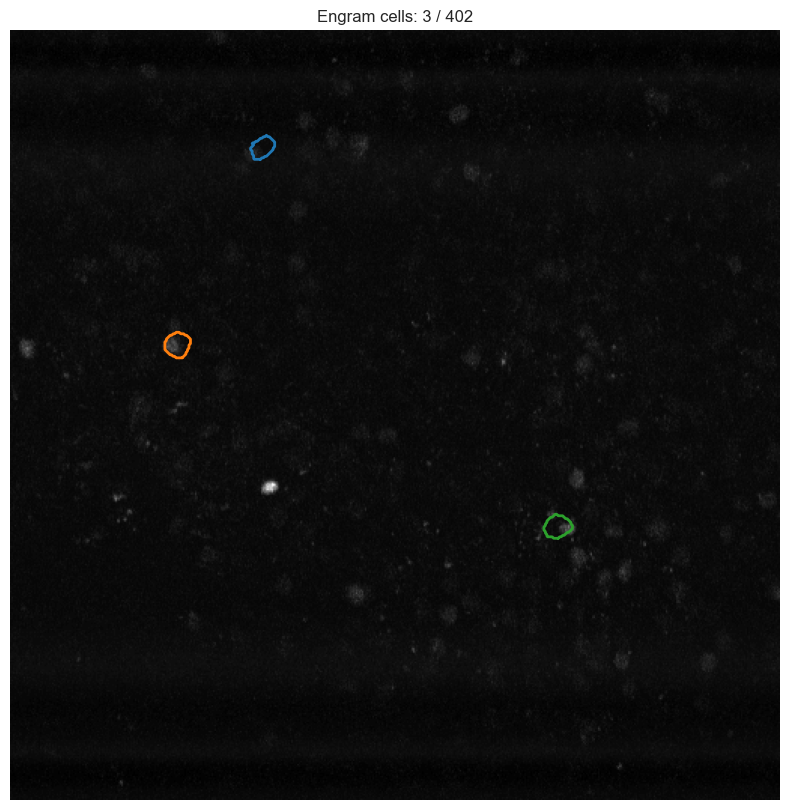

In [22]:
plot_engram_cells(red, stat, is_engram, good)
plt.show()


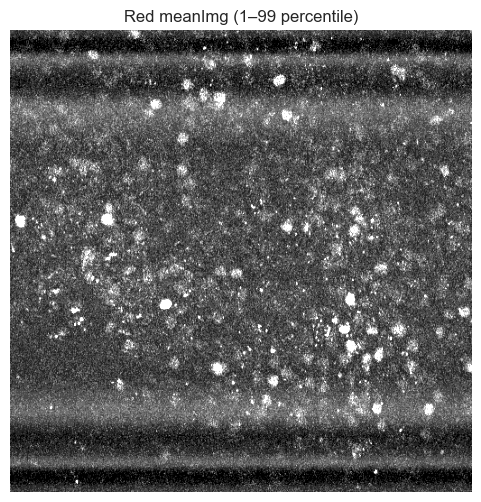

In [19]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

red_mat = "/Users/suthardr/Desktop/akemi/red/Fall_cellsOnly.mat"

with h5py.File(red_mat, "r") as f:
    ops = f["ops"]
    red = np.array(ops["refImg"])

vmin, vmax = np.percentile(red, [1, 99])

plt.figure(figsize=(6, 6))
plt.imshow(red, cmap="gray", vmin=vmin, vmax=vmax)
plt.title("Red meanImg (1–99 percentile)")
plt.axis("off")
plt.show()

